# Climate Risk Index (CRI) Methodology Comparison

## Objective
This notebook reproduces and compares the results of the Climate Risk Index (CRI) across two distinct phases of the DCCE project:
1. **Pilot Phase (TEI)**: Used **OAE (Office of Agricultural Economics)** disaster relief as the proxy for economic loss, averaged over 2559-2566.
2. **Phase 1 (DCCE)**: Used **DDPM (Department of Disaster Prevention and Mitigation)** Government Advance Payments (เงินทดรองราชการ) as the proxy for economic loss, averaged over 2560-2567.

The goal is to analyze how this specific shift in the economic loss proxy—along with temporal adjustments—affects the final vulnerability rankings.

## Methodology Overview

Both phases utilize the same scoring logic based on the Germanwatch Global Climate Risk Index:

### 1. Indicators and Weights
| Category | Indicator | Weight |
| :--- | :--- | :--- |
| **Human Impact (50%)** | Total Deaths (Absolute) | 7.5% |
| | Death Rate (per 100k population) | 22.5% |
| | Total Affected (Absolute) | 5.0% |
| | Affected Rate (per 100k population) | 15.0% |
| **Economic Impact (50%)** | Total Economic Loss (Absolute) | 12.5% |
| | Loss per Unit GPP | 37.5% |

### 2. Normalization
All indicators are normalized using **Min-Max Scaling** to a range of [0, 1].
$$S_i = \frac{X_i - X_{min}}{X_{max} - X_{min}}$$

### 3. Final Score
The final CRI score is the weighted sum of normalized indicators:
$$CRI = \sum_{j=1}^{6} w_j S_j$$
*Note: Higher scores indicate higher climate risk.*

## Data Lineage

### 1. Pilot Phase Datasets (2559-2566)
- **Human Impact**: `casualties_by_hazard_2559_2566.csv` (TEI source). Measures deaths and injuries across four hazards (Flood, Drought, Windstorm, Landslide).
- **Economic Impact**: `relief_by_hazard_2559_2566.csv` (TEI source). Based on OAE agricultural relief data.
- **Denominators**: `population_avg_2559_2566.csv` and `gpp_avg_2559_2566.csv`. GPP is focused on the agricultural sector.

### 2. Phase 1 Datasets (2560-2567)
- **Human Impact**: `fact_ddpm_tambon_impact_climate_2560_2567.csv` (Gold). Derived from standardized DDPM village-level disaster reports.
- **Economic Impact**: `silver_govt_adv_payment_annual_long.csv` (Silver). Public financial proxy using government advance payments for disasters.
- **Denominators**: `silver_population_annual.csv` (Silver - DOPA) and `silver_gpp_annual_long.csv` (Silver - NESDC). GPP covers the total economy at current market prices.

In [83]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
DATA_DIR = "../../data"
PILOT_DIR = os.path.join(DATA_DIR, "0_bronze/tei_pilot")
PHASE1_GOLD_DIR = os.path.join(DATA_DIR, "2_gold/ddpm")
PHASE1_SILVER_DIR = os.path.join(DATA_DIR, "1_silver")

pd.options.display.max_columns = None
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

## 1. Pilot Data Ingestion & Processing (2559-2566)

We load the four core Pilot datasets provided by TEI.

In [84]:
# Load Pilot Data
pilot_casualties = pd.read_csv(os.path.join(PILOT_DIR, "casualties_by_hazard_2559_2566.csv"))
pilot_relief = pd.read_csv(os.path.join(PILOT_DIR, "relief_by_hazard_2559_2566.csv"))
pilot_pop = pd.read_csv(os.path.join(PILOT_DIR, "population_avg_2559_2566.csv"))
pilot_gpp = pd.read_csv(os.path.join(PILOT_DIR, "gpp_avg_2559_2566.csv"))

# 1.0 Province Name Normalization (Applied immediately after loading)
def normalize_province(name):
    if not isinstance(name, str): return name
    name = name.strip()
    if name == "กรุงเทพ": return "กรุงเทพมหานคร"
    if name.startswith("จังหวัด"):
        name = name.replace("จังหวัด", "")
    return name

for df in [pilot_casualties, pilot_relief, pilot_pop, pilot_gpp]:
    df["province_name_th"] = df["province_name_th"].apply(normalize_province)

print(f"Pilot Casualties: {pilot_casualties.shape}")
print(f"Pilot Relief: {pilot_relief.shape}")
print(f"Pilot Population: {pilot_pop.shape}")
print(f"Pilot GPP: {pilot_gpp.shape}")

Pilot Casualties: (308, 5)
Pilot Relief: (308, 4)
Pilot Population: (77, 2)
Pilot GPP: (77, 2)


In [85]:
# 1.1 Pilot Aggregation (Corrected: Both use Total GPP)
pilot_casualties_prov = pilot_casualties.groupby("province_name_th").agg({
    "deaths_count_avg_2559_2566": "sum",
    "injured_count_avg_2559_2566": "sum"
}).reset_index()

pilot_relief_prov = pilot_relief.groupby("province_name_th").agg({
    "relief_amount_avg_2559_2566_baht": "sum"
}).reset_index()

# Aggregate denominators as well in case normalization caused duplicates
pilot_pop_agg = pilot_pop.groupby("province_name_th", as_index=False)["population_avg_2559_2566"].mean()
pilot_gpp_agg = pilot_gpp.groupby("province_name_th", as_index=False)["gpp_avg_2559_2566"].mean()

# Merge all Pilot components
pilot_df = pilot_pop_agg.merge(pilot_gpp_agg, on="province_name_th", how="outer") \
                   .merge(pilot_casualties_prov, on="province_name_th", how="outer") \
                   .merge(pilot_relief_prov, on="province_name_th", how="outer")

# Fill NaNs with 0 for impact metrics
impact_cols = ["deaths_count_avg_2559_2566", "injured_count_avg_2559_2566", "relief_amount_avg_2559_2566_baht"]
pilot_df[impact_cols] = pilot_df[impact_cols].fillna(0)

# Rename for clarity (GPP is TOTAL GPP per user clarification)
pilot_df = pilot_df.rename(columns={
    "population_avg_2559_2566": "pop",
    "gpp_avg_2559_2566": "gpp",
    "deaths_count_avg_2559_2566": "deaths_abs",
    "injured_count_avg_2559_2566": "affected_abs",
    "relief_amount_avg_2559_2566_baht": "loss_abs"
})

# Calculate Rates
pilot_df["death_rate"] = (pilot_df["deaths_abs"] / pilot_df["pop"]) * 100000
pilot_df["affected_rate"] = (pilot_df["affected_abs"] / pilot_df["pop"]) * 100000
# GPP is Million Baht
pilot_df["loss_rate"] = pilot_df["loss_abs"] / (pilot_df["gpp"] * 1000000)

pilot_df.head()

,province_name_th,pop,gpp,deaths_abs,affected_abs,loss_abs,death_rate,affected_rate,loss_rate
0,กระบี่,473639.875,24507.68000,0.750,6066.050,2.087871e+05,0.158348,1280.730428,0.000009
1,กรุงเทพมหานคร,5497670.500,2213.69125,0.000,90.775,2.731562e+05,0.000000,1.651154,0.000123
2,กาญจนบุรี,815728.750,25624.48625,0.250,38307.000,4.090072e+07,0.030647,4696.046327,0.001596
3,กาฬสินธุ์,978258.500,14150.39875,0.625,48724.250,8.363617e+07,0.063889,4980.713176,0.005911
4,กำแพงเพชร,717539.125,23546.20875,0.500,36470.100,5.248029e+07,0.069683,5082.663611,0.002229


In [86]:
# 1.2 Pilot Normalization & Scoring
def calculate_cri(df, prefix=""):
    # Standard columns expected in input DF (no prefix)
    base_cols = ["deaths_abs", "death_rate", "affected_abs", "affected_rate", "loss_abs", "loss_rate"]
    # Correct CRI weights
    weights = [0.075, 0.225, 0.05, 0.15, 0.125, 0.375]
    
    normalized_df = df.copy()
    for col in base_cols:
        s = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
        mn, mx = s.min(), s.max()
        if mx > mn:
            normalized_df[f"score_{col}"] = (s - mn) / (mx - mn)
        else:
            normalized_df[f"score_{col}"] = 0.0
            
    norm_cols = [f"score_{col}" for col in base_cols]
    # Final score column with requested prefix
    normalized_df[f"{prefix}cri_score"] = (normalized_df[norm_cols] * weights).sum(axis=1)
    return normalized_df

pilot_scored = calculate_cri(pilot_df, prefix="pilot_")
pilot_scored["pilot_rank"] = pilot_scored["pilot_cri_score"].rank(ascending=False)
pilot_scored.sort_values("pilot_rank").head(10)

,province_name_th,pop,gpp,deaths_abs,affected_abs,loss_abs,death_rate,affected_rate,loss_rate,score_deaths_abs,score_death_rate,score_affected_abs,score_affected_rate,score_loss_abs,score_loss_rate,pilot_cri_score,pilot_rank
10,ชัยภูมิ,1127928.000,18079.33500,1.000,66731.925,6.528216e+08,0.088658,5916.328436,0.036109,0.238095,0.067555,0.186432,0.116099,0.821460,1.000000,0.537476,1.0
5,ขอนแก่น,1792380.125,22035.37375,3.625,125208.250,5.542284e+08,0.202245,6985.585717,0.025152,0.863095,0.154106,0.349881,0.137088,0.697398,0.696556,0.485847,2.0
18,นครราชสีมา,2631690.875,43429.37750,2.200,108080.750,7.947091e+08,0.083596,4106.893824,0.018299,0.523810,0.063698,0.302007,0.080582,1.000000,0.506772,0.395845,3.0
13,ตราด,219067.625,19516.38625,2.875,33668.250,7.020177e+05,1.312380,15368.884380,0.000036,0.684524,1.000000,0.094014,0.301644,0.000883,0.000996,0.326771,4.0
44,ร้อยเอ็ด,1298737.375,15901.87375,2.125,21375.625,2.922807e+08,0.163620,1645.877405,0.018380,0.505952,0.124675,0.059655,0.032275,0.367783,0.509026,0.310680,5.0
40,ยโสธร,535141.000,7653.65375,1.000,22319.125,1.346468e+08,0.186867,4170.699872,0.017592,0.238095,0.142388,0.062292,0.081834,0.169429,0.487209,0.269166,6.0
37,มหาสารคาม,953911.250,13255.06625,2.375,28724.825,1.672949e+08,0.248975,3011.268082,0.012621,0.565476,0.189713,0.080197,0.059076,0.210511,0.349534,0.255356,7.0
20,นครสวรรค์,1045762.125,32332.71875,0.750,62947.750,3.674431e+08,0.071718,6019.318208,0.011364,0.178571,0.054647,0.175854,0.118121,0.462362,0.314728,0.228018,8.0
76,แม่ฮ่องสอน,239347.875,6715.90750,0.625,121939.500,2.781711e+06,0.261126,50946.556346,0.000414,0.148810,0.198971,0.340744,1.000000,0.003500,0.011471,0.227706,9.0
67,อุทัยธานี,326451.125,10195.55750,0.375,11886.875,1.532275e+08,0.114872,3641.241855,0.015029,0.089286,0.087529,0.033132,0.071442,0.192810,0.416211,0.218944,10.0


## 2. Phase 1 Data Ingestion & Processing (2560-2567)

We load the silver and gold tables developed for Phase 1.

In [87]:
# Load Phase 1 Data
p1_ddpm = pd.read_csv(os.path.join(PHASE1_GOLD_DIR, "fact_ddpm_tambon_impact_climate_2560_2567.csv"))
p1_eco = pd.read_csv(os.path.join(PHASE1_SILVER_DIR, "govt_adv_payment/silver_govt_adv_payment_annual_long.csv"))
p1_gpp = pd.read_csv(os.path.join(PHASE1_SILVER_DIR, "gpp/silver_gpp_annual_long.csv"))
p1_pop = pd.read_csv(os.path.join(PHASE1_SILVER_DIR, "population/silver_population_annual.csv"))

# 2.0 Province Name Normalization (Applied immediately after loading)
for df in [p1_ddpm, p1_eco, p1_gpp, p1_pop]:
    df["province_name_th"] = df["province_name_th"].apply(normalize_province)

print(f"Phase 1 DDPM: {p1_ddpm.shape}")
print(f"Phase 1 Eco Loss: {p1_eco.shape}")
print(f"Phase 1 GPP: {p1_gpp.shape}")
print(f"Phase 1 Population: {p1_pop.shape}")

Phase 1 DDPM: (6967, 13)
Phase 1 Eco Loss: (1848, 23)
Phase 1 GPP: (1848, 24)
Phase 1 Population: (91104, 25)


In [88]:
# 2.1 Phase 1 Aggregation (Averaging over 2560-2567)

# Human Impact: p1_ddpm is already aggregated per subdistrict for the period.
# We sum to province level, then divide by 8 to get the annual average.
p1_human = p1_ddpm.groupby("province_name_th", as_index=False)[["deaths_sum", "affected_people_sum"]].sum()
p1_human["deaths_abs"] = p1_human["deaths_sum"] / 8.0
p1_human["affected_abs"] = p1_human["affected_people_sum"] / 8.0

# Economic Loss: silver_govt_adv_payment_annual_long has annual values.
# We sum hazards per province-year, then average over years.
p1_eco_annual = p1_eco.groupby(["province_name_th", "year_be"], as_index=False)["value"].sum()
p1_eco_prov = p1_eco_annual.groupby("province_name_th", as_index=False)["value"].mean().rename(columns={"value": "loss_abs"})

# Denominators: Mean across years
p1_gpp_prov = p1_gpp[p1_gpp["metric_code"].str.contains("GPP_CURRENT_MARKET_PRICE", na=False)] \
                .groupby("province_name_th", as_index=False)["value"].mean() \
                .rename(columns={"value": "gpp_total"})

# Population: Use 'province' level and average over years
p1_pop_prov = p1_pop[p1_pop["geography_level"] == "province"] \
                .groupby("province_name_th", as_index=False)["population_total"].mean() \
                .rename(columns={"population_total": "pop"})

p1_df = p1_pop_prov.merge(p1_gpp_prov, on="province_name_th", how="outer") \
                   .merge(p1_human[["province_name_th", "deaths_abs", "affected_abs"]], on="province_name_th", how="outer") \
                   .merge(p1_eco_prov, on="province_name_th", how="outer")

p1_df[["deaths_abs", "affected_abs", "loss_abs"]] = p1_df[["deaths_abs", "affected_abs", "loss_abs"]].fillna(0)

# Calculate Rates
p1_df["death_rate"] = (p1_df["deaths_abs"] / p1_df["pop"]) * 100000
p1_df["affected_rate"] = (p1_df["affected_abs"] / p1_df["pop"]) * 100000
# Note: Phase 1 GPP is Total GPP in Million Baht
p1_df["loss_rate"] = p1_df["loss_abs"] / (p1_df["gpp_total"] * 1000000)

p1_scored = calculate_cri(p1_df, prefix="p1_")
p1_scored["p1_rank"] = p1_scored["p1_cri_score"].rank(ascending=False)
p1_scored.sort_values("p1_rank").head(10)

,province_name_th,pop,gpp_total,deaths_abs,affected_abs,loss_abs,death_rate,affected_rate,loss_rate,score_deaths_abs,score_death_rate,score_affected_abs,score_affected_rate,score_loss_abs,score_loss_rate,p1_cri_score,p1_rank
76,แม่ฮ่องสอน,284846.125,15684.673717,0.625,0.125,5.754977e+07,0.219417,0.043883,0.003669,0.208333,0.190977,0.000003,0.000012,0.290669,1.000000,0.469931,1.0
19,นครศรีธรรมราช,1550082.500,180610.143601,2.625,3622.250,1.979342e+08,0.169346,233.681111,0.001096,0.875000,0.147396,0.096638,0.065321,1.000000,0.298672,0.350421,2.0
22,นราธิวาส,809762.625,44903.887045,0.875,28968.625,3.641977e+07,0.108056,3577.421840,0.000811,0.291667,0.094051,0.772857,1.000000,0.183904,0.221036,0.337556,3.0
13,ตราด,228476.250,46211.368823,2.625,832.500,6.382714e+06,1.148916,364.370476,0.000138,0.875000,1.000000,0.022210,0.101853,0.032134,0.037629,0.325141,4.0
29,ปัตตานี,727438.625,50855.973673,3.000,5321.875,3.996140e+07,0.412406,731.590930,0.000786,1.000000,0.358952,0.141983,0.204502,0.201799,0.214144,0.299068,5.0
14,ตาก,673232.750,63929.976651,0.500,3916.125,8.570491e+07,0.074269,581.689616,0.001341,0.166667,0.064642,0.104479,0.162600,0.432931,0.365361,0.247785,6.0
71,เชียงใหม่,1781519.875,257582.638287,2.375,37482.500,1.749528e+07,0.133313,2103.961933,0.000068,0.791667,0.116034,1.000000,0.588122,0.088283,0.018496,0.241673,7.0
59,สุราษฎร์ธานี,1069424.875,211994.046867,2.250,4749.875,6.357287e+07,0.210393,444.152283,0.000300,0.750000,0.183123,0.126722,0.124154,0.321103,0.081716,0.193193,8.0
39,ยะลา,540712.500,49174.254179,1.250,8764.875,8.616366e+06,0.231176,1620.986199,0.000175,0.416667,0.201213,0.233839,0.453116,0.043420,0.047741,0.179512,9.0
33,พัทลุง,522755.125,39992.291442,1.000,305.000,3.531714e+07,0.191294,58.344717,0.000883,0.333333,0.166500,0.008137,0.016309,0.178333,0.240669,0.177858,10.0


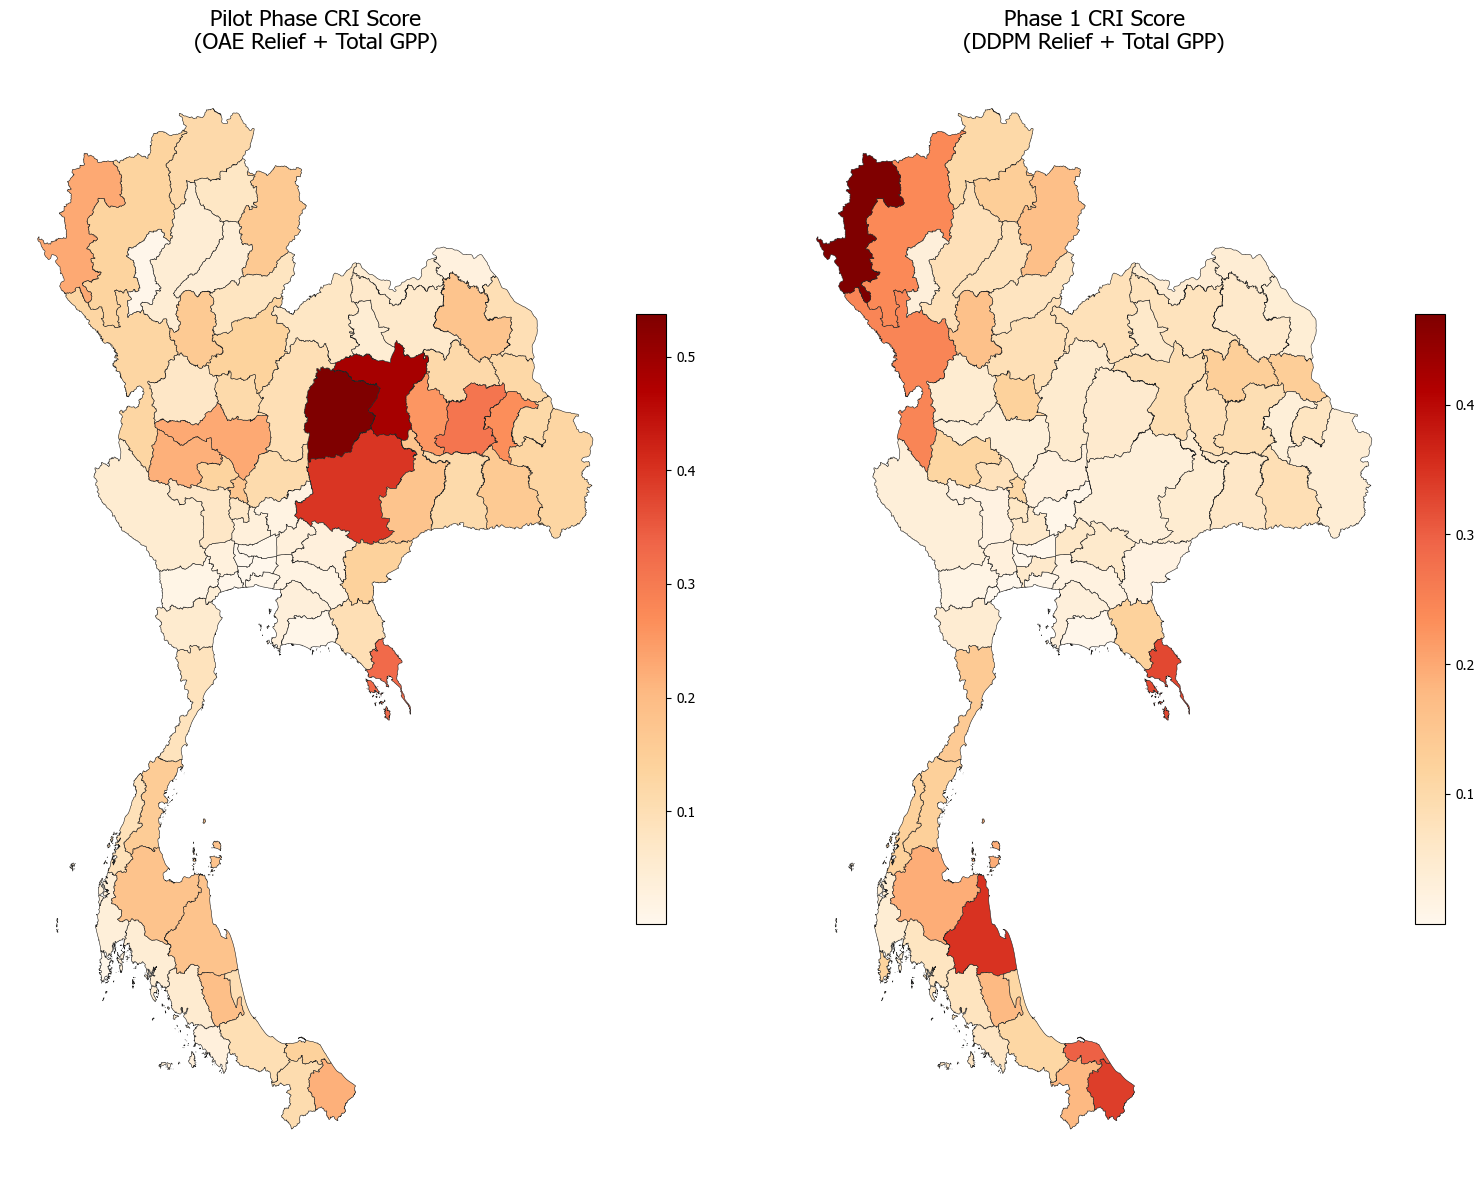

In [89]:
# 2.2 Spatial Visualization: Pilot vs Phase 1 CRI Scores
import geopandas as gpd
import matplotlib.pyplot as plt
import os

def _clean_code_2(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r'(\d+)')[0].fillna('')
    return s.str[-2:].str.zfill(2)

# In order to merge by province_code, we need to load a dataset that maps province_name_th to province_code.
# The Phase 1 population table has both.
pop_lookup = p1_pop[["province_name_th", "province_code"]].drop_duplicates()
pop_lookup["province_code"] = _clean_code_2(pop_lookup["province_code"])

# Merge province_code into our scored dataframes
pilot_mapped = pilot_scored.merge(pop_lookup, on="province_name_th", how="left")
p1_mapped = p1_scored.merge(pop_lookup, on="province_name_th", how="left")

# Load province boundaries
shapefile_path = os.path.join(PHASE1_SILVER_DIR, "dopa/province_boundaries_enriched.shp")
gdf_prov = gpd.read_file(shapefile_path)
if gdf_prov.crs is None or gdf_prov.crs.to_epsg() != 4326:
    gdf_prov = gdf_prov.to_crs(epsg=4326)
gdf_prov = gdf_prov.copy()
gdf_prov['province_code'] = _clean_code_2(gdf_prov['prov_code'])

# Merge geometry with scores
gdf_pilot = gdf_prov.merge(pilot_mapped[["province_code", "pilot_cri_score"]], on="province_code", how="left")
gdf_p1 = gdf_prov.merge(p1_mapped[["province_code", "p1_cri_score"]], on="province_code", how="left")

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# Plot Pilot
axes[0].set_title("Pilot Phase CRI Score\n(OAE Relief + Total GPP)", fontsize=16)
axes[0].set_axis_off()
gdf_pilot.plot(
    column="pilot_cri_score", 
    ax=axes[0], 
    cmap="OrRd", 
    legend=True,
    legend_kwds={'shrink': 0.6, 'fraction': 0.04, 'pad': 0.02},
    linewidth=0.4, 
    edgecolor='#222222', 
    missing_kwds={'color': '#f0f0f0', 'edgecolor': 'none', 'label': 'No data'}
)

# Plot Phase 1
axes[1].set_title("Phase 1 CRI Score\n(DDPM Relief + Total GPP)", fontsize=16)
axes[1].set_axis_off()
gdf_p1.plot(
    column="p1_cri_score", 
    ax=axes[1], 
    cmap="OrRd", 
    legend=True,
    legend_kwds={'shrink': 0.6, 'fraction': 0.04, 'pad': 0.02},
    linewidth=0.4, 
    edgecolor='#222222', 
    missing_kwds={'color': '#f0f0f0', 'edgecolor': 'none', 'label': 'No data'}
)

plt.tight_layout()
plt.show()

## 3. Comparison & Delta Analysis

We merge the results from both phases to analyze the shifts.

In [90]:
# 3.1 Comprehensive Metric Comparison & Delta Calculation
import numpy as np

base_metrics = ["deaths_abs", "death_rate", "affected_abs", "affected_rate", "loss_abs", "loss_rate"]

# Select core columns for comparison
# Corrected column names based on pilot_scored and p1_scored structure
score_cols = [f"score_{m}" for m in base_metrics]
pilot_cols = ["province_name_th", "pilot_cri_score", "pilot_rank", "gpp", "pop"] + base_metrics + score_cols
p1_cols = ["province_name_th", "p1_cri_score", "p1_rank", "gpp_total", "pop"] + base_metrics + score_cols

comparison_df = pilot_scored[pilot_cols].merge(
    p1_scored[p1_cols], 
    on="province_name_th", how="inner", suffixes=('_pilot', '_p1')
)

# Calculate Deltas for all 6 metrics
for m in base_metrics:
    # Absolute Difference
    comparison_df[f"{m}_delta"] = comparison_df[f"{m}_p1"] - comparison_df[f"{m}_pilot"]
    # Percentage Difference (avoiding division by zero)
    comparison_df[f"{m}_pct_diff"] = (comparison_df[f"{m}_delta"] / comparison_df[f"{m}_pilot"].replace(0, np.nan)) * 100

# GPP and Population Comparison (Phase 1 gpp_total vs Pilot gpp)
comparison_df["gpp_ratio"] = comparison_df["gpp_total"] / comparison_df["gpp"]
comparison_df["pop_ratio"] = comparison_df["pop_p1"] / comparison_df["pop_pilot"]
comparison_df["rank_shift"] = comparison_df["pilot_rank"] - comparison_df["p1_rank"]

print(f"Comparison Table created with {len(comparison_df)} provinces.")

Comparison Table created with 77 provinces.


In [91]:
# 3.3 Detailed Metric Discrepancy Audit
def show_top_discrepancies(metric_name, n=10):
    print(f"\n--- Top {n} Discrepancies for: {metric_name} ---")
    cols = [
        "province_name_th", 
        f"{metric_name}_pilot", f"{metric_name}_p1", 
        f"{metric_name}_delta", f"{metric_name}_pct_diff",
        "rank_shift"
    ]
    # Sort by absolute delta to find largest numeric mismatches
    df_top = comparison_df.sort_values(f"{metric_name}_delta", key=abs, ascending=False).head(n)
    display(df_top[cols])

# Show audit for Human Impact vs Economic Impact
show_top_discrepancies("deaths_abs")
show_top_discrepancies("loss_abs")
show_top_discrepancies("loss_rate")

print("\n--- Denominator Audit (GPP & Population) ---")
den_cols = ["province_name_th", "gpp", "gpp_total", "gpp_ratio", "pop_pilot", "pop_p1", "pop_ratio"]
display(comparison_df.sort_values("gpp_ratio", ascending=False).head(10)[den_cols])


--- Top 10 Discrepancies for: deaths_abs ---


,province_name_th,deaths_abs_pilot,deaths_abs_p1,deaths_abs_delta,deaths_abs_pct_diff,rank_shift
22,นราธิวาส,3.625,0.875,-2.75,-75.862069,8.0
5,ขอนแก่น,3.625,1.625,-2.00,-55.172414,-24.0
59,สุราษฎร์ธานี,4.200,2.250,-1.95,-46.428571,5.0
71,เชียงใหม่,0.625,2.375,1.75,280.000000,19.0
45,ลพบุรี,1.875,0.125,-1.75,-93.333333,-31.0
18,นครราชสีมา,2.200,0.500,-1.70,-77.272727,-59.0
35,พิษณุโลก,2.450,0.750,-1.70,-69.387755,-5.0
36,ภูเก็ต,0.125,1.625,1.50,1200.000000,51.0
37,มหาสารคาม,2.375,0.875,-1.50,-63.157895,-23.0
49,สกลนคร,2.000,0.500,-1.50,-75.000000,-31.0



--- Top 10 Discrepancies for: loss_abs ---


,province_name_th,loss_abs_pilot,loss_abs_p1,loss_abs_delta,loss_abs_pct_diff,rank_shift
18,นครราชสีมา,7.947091e+08,7.045999e+06,-7.876631e+08,-99.113386,-59.0
10,ชัยภูมิ,6.528216e+08,6.691154e+06,-6.461304e+08,-98.975041,-48.0
5,ขอนแก่น,5.542284e+08,2.269832e+07,-5.315301e+08,-95.904519,-24.0
20,นครสวรรค์,3.674431e+08,4.451625e+06,-3.629914e+08,-98.788486,-52.0
44,ร้อยเอ็ด,2.922807e+08,1.771343e+07,-2.745673e+08,-93.939581,-22.0
25,บุรีรัมย์,2.429911e+08,2.080375e+07,-2.221874e+08,-91.438473,-36.0
19,นครศรีธรรมราช,3.955303e+07,1.979342e+08,1.583812e+08,400.427401,12.0
68,อุบลราชธานี,1.748407e+08,2.019338e+07,-1.546473e+08,-88.450408,-30.0
37,มหาสารคาม,1.672949e+08,1.909504e+07,-1.481999e+08,-88.586002,-23.0
67,อุทัยธานี,1.532275e+08,1.942683e+07,-1.338007e+08,-87.321579,-12.0



--- Top 10 Discrepancies for: loss_rate ---


,province_name_th,loss_rate_pilot,loss_rate_p1,loss_rate_delta,loss_rate_pct_diff,rank_shift
10,ชัยภูมิ,0.036109,0.000095,-0.036014,-99.737192,-48.0
5,ขอนแก่น,0.025152,0.000105,-0.025047,-99.583464,-24.0
18,นครราชสีมา,0.018299,0.000022,-0.018277,-99.877940,-59.0
44,ร้อยเอ็ด,0.018380,0.000217,-0.018163,-98.817294,-22.0
40,ยโสธร,0.017592,0.000217,-0.017375,-98.764522,-53.0
67,อุทัยธานี,0.015029,0.000644,-0.014385,-95.717315,-12.0
37,มหาสารคาม,0.012621,0.000297,-0.012324,-97.647092,-23.0
20,นครสวรรค์,0.011364,0.000038,-0.011327,-99.666697,-52.0
25,บุรีรัมย์,0.011014,0.000214,-0.010800,-98.055442,-36.0
64,อำนาจเจริญ,0.009651,0.000504,-0.009147,-94.777503,-9.0



--- Denominator Audit (GPP & Population) ---


,province_name_th,gpp,gpp_total,gpp_ratio,pop_pilot,pop_p1,pop_ratio
1,กรุงเทพมหานคร,2213.69125,5.620290e+06,2538.877055,5497670.500,5570385.375,1.013226
52,สมุทรปราการ,3993.66250,7.292439e+05,182.600295,1321755.625,1350525.000,1.021766
21,นนทบุรี,4621.47875,3.593720e+05,77.761261,1255698.625,1278590.750,1.018231
26,ปทุมธานี,5862.67625,4.308802e+05,73.495472,1157937.000,1182810.625,1.021481
8,ชลบุรี,19436.87125,1.058835e+06,54.475612,1535817.250,1575222.125,1.025657
54,สมุทรสาคร,8709.85125,4.151149e+05,47.660390,547908.750,584556.000,1.066886
42,ระยอง,25124.73125,1.010719e+06,40.228039,729627.125,746864.750,1.023625
30,พระนครศรีอยุธยา,10763.99875,4.078915e+05,37.894048,815928.625,819540.500,1.004427
28,ปราจีนบุรี,8657.92000,2.979753e+05,34.416494,492184.875,495100.875,1.005925
36,ภูเก็ต,6966.11500,1.981720e+05,28.448000,401421.250,416642.375,1.037918


C:\Users\sitth\AppData\Local\Temp\ipykernel_13868\1697503805.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_series.values, y=metrics_series.index, palette="Reds_r")


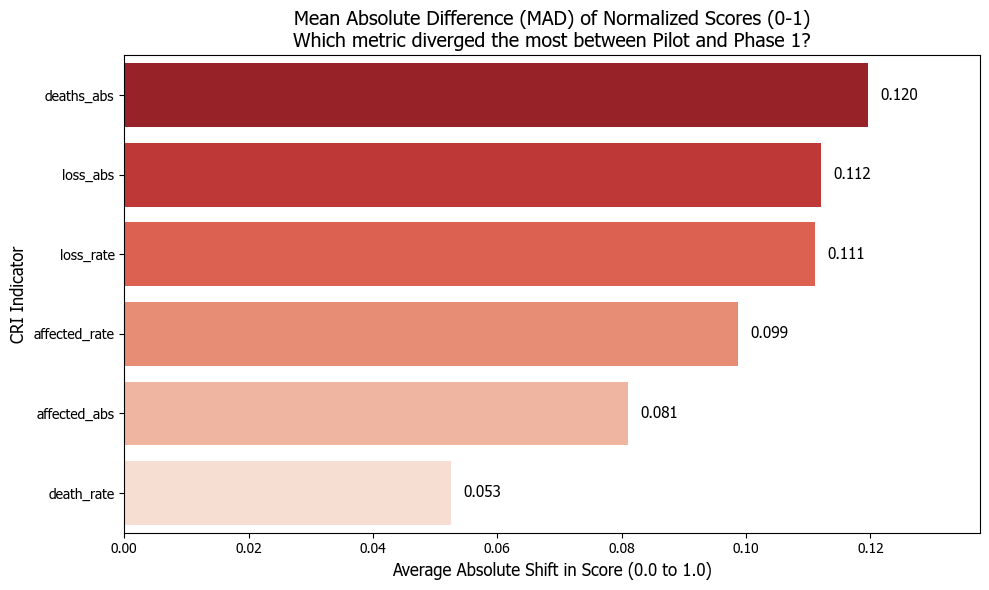


--- Visual Interpretation ---
This chart shows the average absolute difference in the 0-1 normalized scores for each indicator.
A higher bar means that the relative ranking/scoring for that specific metric changed drastically between the Pilot data and Phase 1 data.


In [92]:
# 3.4 Visualizing the Discrepancy (Normalized Scores)
# To compare metrics with different units, we compare their 0-to-1 normalized scores.
import matplotlib.pyplot as plt
import seaborn as sns

mad_scores = {}
for m in base_metrics:
    pilot_col = f"score_{m}_pilot"
    p1_col = f"score_{m}_p1"
    # Mean Absolute Difference of the 0-1 scores
    mad = (comparison_df[p1_col] - comparison_df[pilot_col]).abs().mean()
    mad_scores[m] = mad

# Plotting
plt.figure(figsize=(10, 6))
metrics_series = pd.Series(mad_scores).sort_values(ascending=False)
sns.barplot(x=metrics_series.values, y=metrics_series.index, palette="Reds_r")
plt.title("Mean Absolute Difference (MAD) of Normalized Scores (0-1)\nWhich metric diverged the most between Pilot and Phase 1?", fontsize=14)
plt.xlabel("Average Absolute Shift in Score (0.0 to 1.0)", fontsize=12)
plt.ylabel("CRI Indicator", fontsize=12)

for i, v in enumerate(metrics_series.values):
    plt.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=11)

plt.xlim(0, metrics_series.max() * 1.15)
plt.tight_layout()
plt.show()

print("\n--- Visual Interpretation ---")
print("This chart shows the average absolute difference in the 0-1 normalized scores for each indicator.")
print("A higher bar means that the relative ranking/scoring for that specific metric changed drastically between the Pilot data and Phase 1 data.")

## 4. Interpretation of Discrepancies

Based on the quantitative audit and methodology review, the massive rank shifts are driven primarily by the **Economic Loss Proxy (Numerator)**.

### 1. The Numerator Shift: OAE vs. DDPM
The most significant driver of the discrepancy is the shift in the data source for `Loss_abs`:
- **Pilot (OAE)**: Represents agricultural compensation. In rural/agricultural provinces (like Nakhon Ratchasima, Chaiyaphum), these values can be massive because crop damage covers vast geographic areas.
- **Phase 1 (DDPM)**: Represents "เงินทดรองราชการ" (Government Advance Payment). This is an emergency budget used for immediate relief. It is historically capped (e.g., 20 million baht per province per disaster declaration). Therefore, even in a catastrophic flood, the DDPM reported financial loss will artificially hit a ceiling and appear much lower than the OAE agricultural loss.

**Impact:** Provinces heavily reliant on agriculture experienced a massive **Rank Drop** in Phase 1 because their astronomical OAE losses were replaced by capped, much smaller DDPM advance payments. 

### 2. The Denominator Reality: Total GPP
Both phases use **NESDC Total GPP** as the denominator for the `Loss Rate`. 
- Because Total GPP includes manufacturing, services, and industry, dividing a purely agricultural loss (Pilot) by Total GPP creates a specific mathematical dynamic: provinces where agriculture makes up a smaller fraction of the total economy (but absolute crop damage is high) see their risk diluted. 
- When Phase 1 switched the numerator to DDPM advance payments, the already diluted `Loss Rate` became infinitesimally small for almost all provinces, severely compressing the scoring range.

### 3. Temporal and Aggregation Shifts
While secondary to the OAE vs DDPM proxy shift, the temporal window (2559-2566 vs 2560-2567) and the strict pipeline spatial roll-up rules in Phase 1 (handling of zero vs NaN) caused the remaining variations in Human Impact (Deaths and Affected).